# Charge Gate Ramsey Analysis
Load a pre-parsed `xarray.Dataset` from an `.h5` file and run `ChargeGateRamseyAnalyzer`.

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from scqat.protocols.charge_gate_ramsey import ChargeGateRamseyAnalyzer
from scqat.parsers.xarray_h5_parser import load_xarray_h5
from scqat.parsers.qualibrate_parser import repetition_data

## 1. Configuration

In [8]:
# Path to the pre-parsed xarray Dataset stored as NetCDF4/HDF5
H5_PATH = r"d:\github\LCHQMDriver\data\QPU_project\2026-04-07\#3860_LCH_charge_gate_ramsey_222940\ds_raw.h5"

# Optional: directory for saving outputs (set to None to skip saving)
OUTPUT_DIR = None

# Name of the variable in the dataset to use as the signal
# Common choices: "state", "I"
SIGNAL_VAR = "I"

# Optional analysis kwargs
ANALYSIS_KWARGS = {
    # "force_model": "beat",       # force damped beat for every charge-gate slice
    "f_c_fixed": 0.1e-3,        # user-supplied centre frequency (skip auto-calc)
    "abscos_frequency_hint": 0.6,  # seed for |cos| fit frequency (V^-1)
}

## 2. Load Dataset

In [9]:
dataset = load_xarray_h5(H5_PATH)
dataset

<xarray.Dataset> Size: 15kB
Dimensions:      (idle_time: 100, charge_gate: 6, qubit: 1)
Coordinates:
  * idle_time    (idle_time) int32 400B 16 1632 3248 ... 156768 158384 160000
  * charge_gate  (charge_gate) float64 48B -0.45 -0.27 -0.09 0.09 0.27 0.45
  * qubit        (qubit) object 8B 'q1'
Data variables:
    I1           (qubit, charge_gate, idle_time) int32 2kB 0 0 0 0 0 ... 0 0 0 0
    Q1           (qubit, charge_gate, idle_time) int32 2kB 0 0 0 0 0 ... 0 0 0 0
    I            (qubit, charge_gate, idle_time) float64 5kB 0.001974 ... 0.0...
    Q            (qubit, charge_gate, idle_time) float64 5kB -0.0006176 ... -...

In [10]:
# Split by qubit and pick the first one
sq_data = repetition_data(dataset)[0]

# Rename the chosen variable to 'signal' so the analyzer can find it
if SIGNAL_VAR != 'signal' and SIGNAL_VAR in sq_data:
    sq_data = sq_data.rename({SIGNAL_VAR: 'signal'})

sq_data

<xarray.Dataset> Size: 15kB
Dimensions:      (idle_time: 100, charge_gate: 6)
Coordinates:
  * idle_time    (idle_time) int32 400B 16 1632 3248 ... 156768 158384 160000
  * charge_gate  (charge_gate) float64 48B -0.45 -0.27 -0.09 0.09 0.27 0.45
    qubit        <U2 8B 'q1'
Data variables:
    I1           (charge_gate, idle_time) int32 2kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    Q1           (charge_gate, idle_time) int32 2kB 0 0 0 0 0 0 ... 0 0 0 0 0 0
    signal       (charge_gate, idle_time) float64 5kB 0.001974 ... 0.002068
    Q            (charge_gate, idle_time) float64 5kB -0.0006176 ... -0.0005533

## 3. Run Analysis

In [11]:
analyzer = ChargeGateRamseyAnalyzer()
results, figs = analyzer.analyze(
    sq_data,
    output_dir=OUTPUT_DIR,
    **ANALYSIS_KWARGS,
)

## 4. Display Figures

--- raw_colormap ---


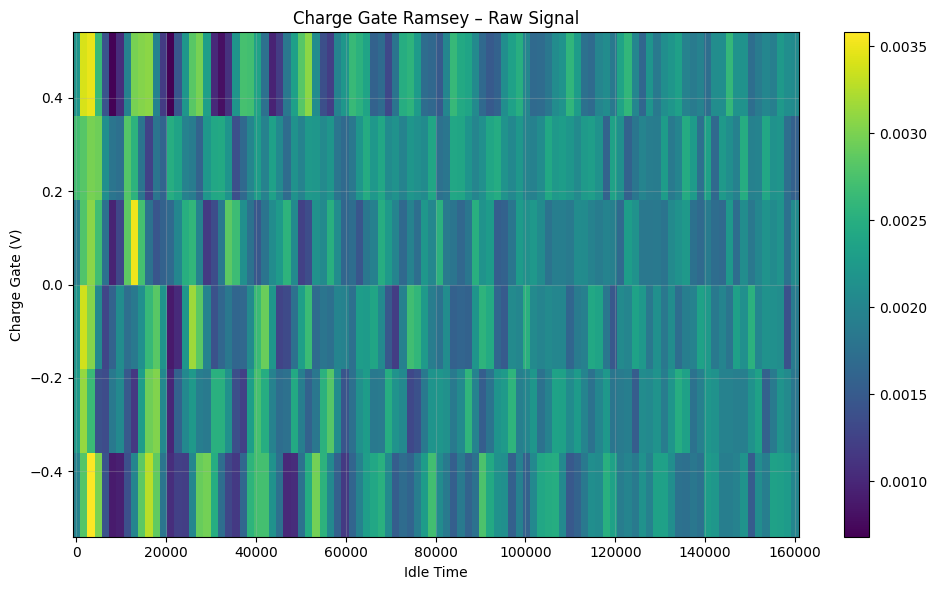

--- fft_spectrum ---


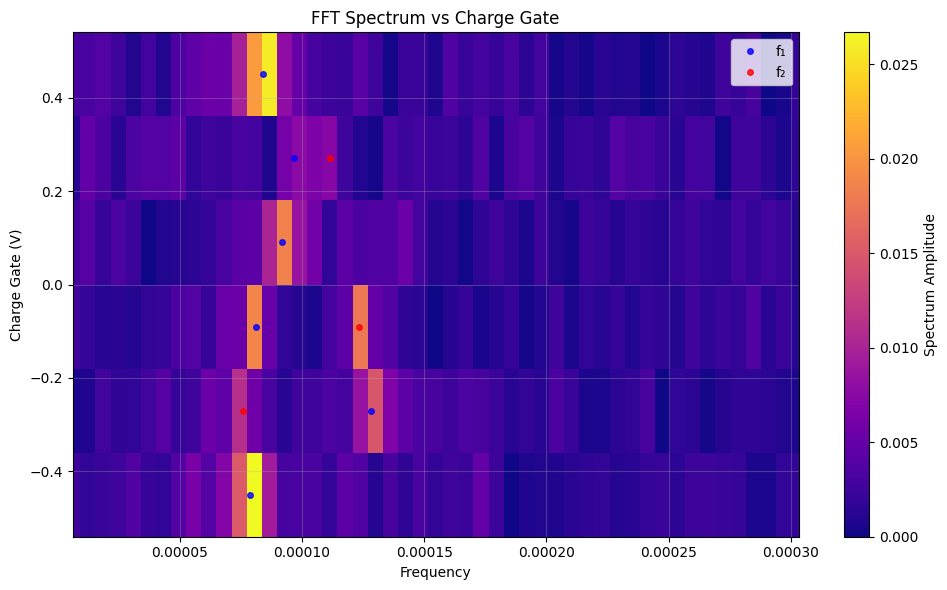

--- freq_vs_charge_gate ---


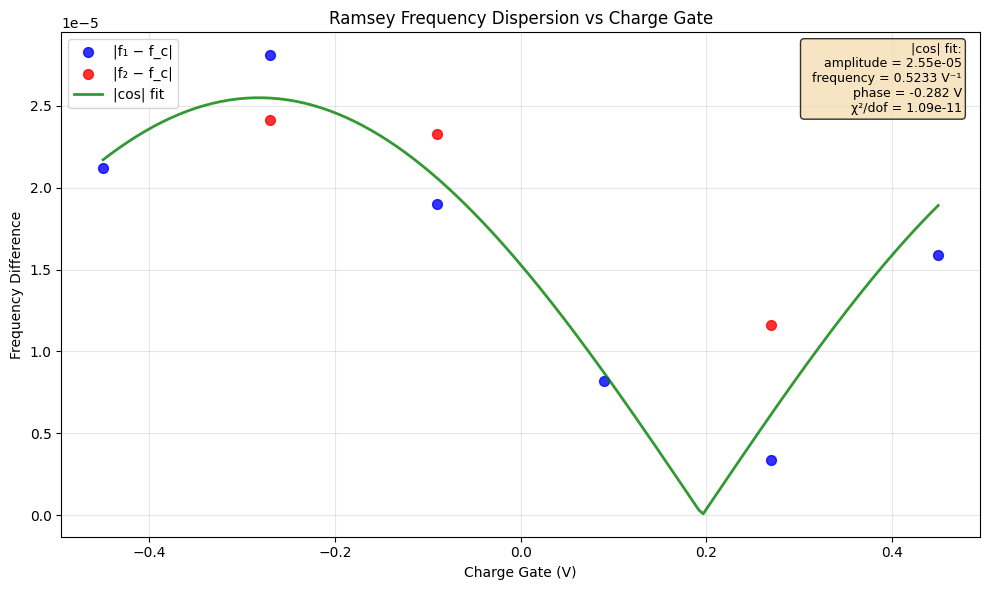

In [12]:
for name, fig in figs.items():
    print(f"--- {name} ---")
    display(fig)
    plt.close(fig)

## 5. Inspect Results

In [13]:
import numpy as np

print(f"Centre frequency f_c = {results['f_c']:.6g}")
print()

# Per charge-gate summary
for i, cg in enumerate(results['charge_gates']):
    mt = results['model_types'][i]
    f1 = results['f_1'][i]
    f2 = results['f_2'][i]
    line = f"  charge_gate={cg:.4f}  model={mt or 'FAILED':>6s}  f_1={f1:.6g}"
    if not np.isnan(f2):
        line += f"  f_2={f2:.6g}"
    print(line)

# |cos| fit summary
print()
abscos = results.get('abscos_params')
if abscos and abscos.get('success'):
    print("|cos| fit results:")
    print(f"  amplitude = {abscos['amplitude']:.6g}")
    print(f"  frequency = {abscos['frequency']:.6g} V⁻¹")
    print(f"  phase     = {abscos['phase']:.6g} V")
    print(f"  χ²/dof    = {abscos['redchi']:.6g}")
else:
    print("|cos| fit did not converge or insufficient data.")

Centre frequency f_c = 0.0001

  charge_gate=-0.4500  model=single  f_1=7.87727e-05
  charge_gate=-0.2700  model=  beat  f_1=0.000128091  f_2=7.58626e-05
  charge_gate=-0.0900  model=  beat  f_1=8.09913e-05  f_2=0.000123283
  charge_gate=0.0900  model=single  f_1=9.17789e-05
  charge_gate=0.2700  model=  beat  f_1=9.66315e-05  f_2=0.000111596
  charge_gate=0.4500  model=single  f_1=8.4121e-05

|cos| fit results:
  amplitude = 2.54968e-05
  frequency = 0.523312 V⁻¹
  phase     = -0.28197 V
  χ²/dof    = 1.08994e-11
